**REPORT**

**Standard imports**

In [539]:
# Standard imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import itertools

# Required for modeling and evaluation
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report,ConfusionMatrixDisplay 
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson


## Section 1 - Data and Pre-Processing

**Steps in this section**

1. Read the raw data downlaoded from CDC webiste
2. Select columns related to cardio vascualar diseases and the relevant features and assign meaningful names
3. Check data missing values and % and treat missing values 
4. Code variables inline with CDC documentation and create approprite classes 


**Read raw data**

In [552]:
cdc_raw_2023 = pd.read_sas(r'G:\My Drive\PROFESSIONAL\MAS24\Courses\M569_STAT_LRN\assignment\FINAL\cdc\raw\LLCP2023XPT\LLCP2023.XPT', format='xport')
print('\nRaw data shape :',cdc_raw_2023.shape)

# Select list of column names for  analysis
data_cols_to_keep = [
    '_MICHD',  # Ever reported having coronary heart disease (CHD) or myocardial infarction (MI) - CVDCRHD4= 1 & CVDINFR4 =1
    '_RFHYPE6',  # Hypertension risk factor
    '_RFCHOL3',  # Cholesterol risk factor  
    '_RFBMI5',  # Obese or not based on BMI >25
    '_RFSMOK3',  # Smoking risk factor
    'CVDSTRK3',  # Cardiovascular stroke indicator
    'EXERANY2',  # Exercise indicator
    '_TOTINDA',  # Exerise any in last 30 days   
    '_RFDRHV8',  # Heavy drinking risk factor
    'DIFFWALK',  # Difficulty walking
    'CHECKUP1',  # Checkup frequency
    # Social-Economic factors
    '_HLTHPL1',    # Health plan
    '_AGEG5YR',    # Age group (5-year)
    '_EDUCAG',     # Education level
    'INCOME3'     # Income level categories 
    ]

variable_name_mapping = {
    '_MICHD': 'has_heart_disease',                   # CHD or MI indicator
    '_RFHYPE6': 'hypertension_risk',                 # Hypertension risk factor
    '_RFCHOL3': 'cholesterol_risk',                  # Cholesterol risk factor
    '_RFBMI5': 'obese_status',                       # Obese (BMI > 25)
    '_RFSMOK3': 'smoking_risk',                      # Smoking risk factor
    'CVDSTRK3': 'stroke_history',                    # Ever had a stroke
    
    'EXERANY2': 'exercised_recently',                # Any exercise in last 30 days
    '_TOTINDA': 'physically_active',                 # Total physical activity
    
    '_RFDRHV8': 'heavy_drinking_risk',               # Heavy drinking risk factor
    'DIFFWALK': 'difficulty_walking',                # Difficulty walking
    'CHECKUP1': 'checkup_frequency',                 # Frequency of health checkups

    '_HLTHPL1': 'has_health_plan',                   # Health insurance coverage
    '_AGEG5YR': 'age_group',                         # Age group (5-year bins)
    '_EDUCAG': 'education_level',                    # Education level
    'INCOME3': 'income_category'                     # Income level category
}

# Extract relevant columns and rename them
cvd = cdc_raw_2023.loc[:, data_cols_to_keep].copy()
cvd.columns = list(variable_name_mapping.values())
print('\n cvd data shape :', cvd.shape)


Raw data shape : (433323, 350)

 cvd data shape : (433323, 15)


**User Defined Functions - Section 1** 


In [194]:
def calculate_missing_count_n_plot(input_df):
    # Calculate missing values count and percentage for each columns
    missing_count = input_df.isnull().sum()
    missing_percent = (input_df.isnull().mean() * 100).round(2)
    
    # Combine into a DataFrame for plotting
    missing_df = pd.DataFrame({
        'Missing Count': missing_count,
        'Missing %': missing_percent
    })
    
    # Plot both missing count and percent as side-by-side bars
    plt.figure(figsize=(12, 8))
    missing_df.plot(kind='bar', secondary_y='Missing %', colormap='tab10', legend=True)
    plt.title("Missing Value Count and Percentage by Column, 5% Threshold")
    plt.xlabel("Column Name")
    plt.xticks(rotation=90, ha='right')
    plt.axhline(5, color='orange', linestyle=':', linewidth=2)
    plt.tight_layout()
    plt.show()
    
    # Check the unique categories of data and reconsile these definitions with CDC data dictionary
    summary = []
    for col in input_df.columns:
        value_percent = (input_df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
        num_unique = value_percent.shape[0]
        summary.append({
            'Column': col,
            'Num Unique': num_unique,
            'Value Percents': value_percent.to_dict()
        })
    
    summary_df = pd.DataFrame(summary)
    print (summary_df)



def del_missing_replace_col_values(in_df, col_name, miss_code, c1=99, c1_replace=99, 
                                   c2=999,c2_replace=999,
                                   c3=9999,c3_replace=9999,
                                   c4=99999,c4_replace = 99999):
    '''
    Take in a dataframe with cols which have missing values which we want to delete based on the value of the codes i.e. 7,9
    We also change some coded values to better suit our analysis, e.g. No is coded 0 and Yes as 1 or to collapse multiple categories into single
    Makes changes to the original dataframe so be careful
    '''
    # Del miss code
    in_df[col_name]
    in_df = in_df[~in_df[col_name].isin(miss_code)]
    replace_dict = {c1:c1_replace, c2:c2_replace, c3:c3_replace,c4:c4_replace}
    
    in_df.loc[:,col_name] = in_df[col_name].replace(replace_dict)
    
    return in_df


**Check missing values in input dataset**

<Figure size 1200x800 with 0 Axes>

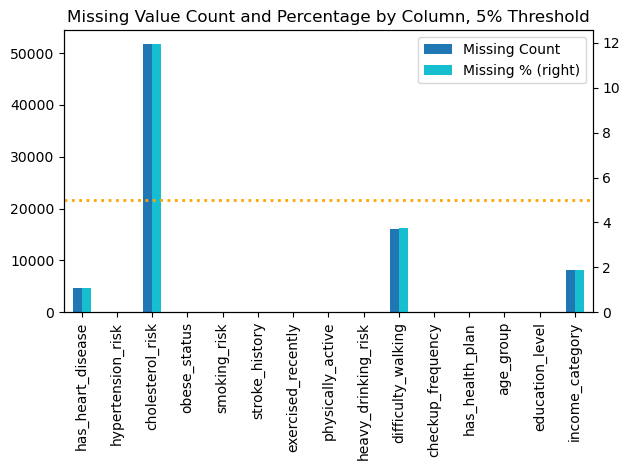

                 Column  Num Unique  \
0     has_heart_disease           3   
1     hypertension_risk           3   
2      cholesterol_risk           4   
3          obese_status           3   
4          smoking_risk           3   
5        stroke_history           5   
6    exercised_recently           5   
7     physically_active           3   
8   heavy_drinking_risk           3   
9    difficulty_walking           5   
10    checkup_frequency           8   
11      has_health_plan           3   
12            age_group          14   
13      education_level           5   
14      income_category          14   

                                       Value Percents  
0                  {2.0: 90.56, 1.0: 8.38, nan: 1.06}  
1                 {1.0: 58.89, 2.0: 40.67, 9.0: 0.44}  
2     {1.0: 50.62, 2.0: 36.67, nan: 11.96, 9.0: 0.76}  
3                  {2.0: 62.2, 1.0: 28.45, 9.0: 9.35}  
4                 {1.0: 84.26, 2.0: 10.42, 9.0: 5.32}  
5   {2.0: 95.43, 1.0: 4.23, 7.0: 0.28, 

In [196]:
calculate_missing_count_n_plot(input_df=cvd)

**Given the large dataset, we will delete null values i.e. usually code values 7,9. We will combine categoris as appropiate based on CDC data dictionary and assign 0,1,2 codes, please note we don't ncessarily need ordinal values. Each variable is coded differently and as such treated these separately**

In [203]:
# delete missing values
cvd_clean = cvd.dropna()
        
# 'has_heart_disease','_MICHD' - Ever reported having coronary heart disease (CHD) or myocardial infarction (MI)
'''
Code 1 - Yes, Reported having MI or CHD 
Code 2 - Did not report having MI or CHD, change to 0  
Code BLANK - Missing data
'''

cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='has_heart_disease', 
                               miss_code =[''],
                               c1=2, c1_replace=0,
                                                                       
                                )

# 'hypertension_risk', '_RFHYPE6'  -  Adults who have been told they have high blood pressure by a doctor, nurse, or other health professional
'''
Code 1 - No, change it to 0 
Code 2 - Yes, change it to 1 
Code 9 - Missing data, delete
'''
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='hypertension_risk', 
                               miss_code =[9], 
                               c1=1, c1_replace=0, 
                               c2=2, c2_replace=1                             
                                )


# 'cholesterol_risk', '_RFCHOL3'  -  Cholesterol checked and have been told by a doctor, nurse, or other health professional that it was high
'''
Code 1 - No, change it to 0 
Code 2 - Yes, change it to 1 
Code 9 - Missing data, delete
Code BLANK - Missing data, delete
'''
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='cholesterol_risk', 
                               miss_code =['',9], 
                               c1=1, c1_replace=0, 
                               c2=2, c2_replace=1                             
                                )


# 'obese_status', '_RFBMI5'  -   Adults who have a body mass index greater than 25.00 (Overweight or Obese)
'''
Code 1 - No, change it to 0 
Code 2 - Yes, change it to 1 
Code 9 - Missing data, delete
Code BLANK - Missing data, delete
'''
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='obese_status', 
                               miss_code =['',9], 
                               c1=1, c1_replace=0, 
                               c2=2, c2_replace=1                             
                                )


# 'smoking_risk', '_RFSMOK3'  -  Adults who are current smokers
'''
Code 1 - No, change it to 0 
Code 2 - Yes, change it to 1 
Code 9 - Missing data, delete
Code BLANK - Missing data, delete
'''
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='smoking_risk', 
                               miss_code =['',9], 
                               c1=1, c1_replace=0, 
                               c2=2, c2_replace=1                             
                                )



# 'stroke_history', 'CVDSTRK3'  -  Adults who are current smokers
'''
Code 1 - Yes, keep as 1
Code 2 - No, change it to 0 
Code 7,9 - Missing data, delete
Code BLANK - Missing data, delete
'''
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='stroke_history', 
                               miss_code =['',7,9], 
                               c1=1, c1_replace=1, 
                               c2=2, c2_replace=0                             
                                )

# 'exercised_recently', 'EXERANY2'  - During the past month, other than your regular job, did you participate in any physical activities or exercises such as running, calisthenics, golf, gardening, or walking for exercise?
'''
Code 1 - Yes, keep as 1
Code 2 - No, change it to 0 
Code 7,9 - Missing data, delete
Code BLANK - Missing data, delete
'''
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='exercised_recently', 
                               miss_code =['',7,9], 
                               c1=1, c1_replace=1, 
                               c2=2, c2_replace=0                             
                                )


# 'physically_active', '_TOTINDA'  - Adults who reported doing physical activity or exercise during the past 30 days other than their regular job
'''
Code 1 - Yes, keep as 1
Code 2 - No, change it to 0 
Code 7,9 - Missing data, delete
Code BLANK - Missing data, delete
'''
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='physically_active', 
                               miss_code =['',7,9], 
                               c1=1, c1_replace=1, 
                               c2=2, c2_replace=0                             
                                )


# 'heavy_drinking_risk', '_RFDRHV8'  - Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 drinks per week)
'''
Code 1 - No, change to 0
Code 2 - yes, change it to 1 
Code 7,9 - Missing data, delete
Code BLANK - Missing data, delete
'''
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='heavy_drinking_risk', 
                               miss_code =['',7,9], 
                               c1=1, c1_replace=0, 
                               c2=2, c2_replace=1                             
                                )



# 'difficulty_walking', 'DIFFWALK'  - Do you have serious difficulty walking or climbing stairs?
'''
Code 1 - Yes, keep 1
Code 2 - No, change it to 0
Code 7,9 - Missing data, delete
Code BLANK - Missing data, delete
'''
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='difficulty_walking', 
                               miss_code =['',7,9], 
                               c1=1, c1_replace=1, 
                               c2=2, c2_replace=0                             
                                )



# 'checkup_frequency', 'CHECKUP1'  - About how long has it been since you last visited a doctor for a routine checkup?
'''
Code 1 - Last 12 months
Code 2 - Last 24 months
Code 3 - Last 60 months
Code 4 - More than 60 months
Code 8 - NEVER - code it 5 (worst value)

Code 7,9 - Missing data, delete
Code BLANK - Missing data, delete
'''
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='checkup_frequency', 
                               miss_code =['',7,9], 
                               c1=8, c1_replace=5
                                    
                                )



# 'has_health_plan', '_HLTHPL1'  - Adults who had some form of health insurance
'''
Code 1 - Yes, code 1
Code 2 - No, code 0

Code 7,9 - Missing data, delete
Code BLANK - Missing data, delete
'''
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='has_health_plan', 
                               miss_code =['',7,9], 
                               c1=1, c1_replace=1, 
                               c2=2, c2_replace=0    
                                )


# 'age_group', '_AGEG5YR',	AGE - 14 is dont know, refused answer, rest all are 13 categories starting 18-24 years
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='age_group', 
                               miss_code =[14])



# 'education_level', '_EDUCAG'  - 9 is dont know, refused answer, Rest range from 1-4 from no high school to graduate
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='education_level', 
                               miss_code =[9])

# 'income_category', 'INCOME3' - 77,99 is dont know, refused answer, Rest range from 1-7 from less than 15k to more than 200K 
cvd_clean= del_missing_replace_col_values(in_df=cvd_clean , 
                               col_name ='income_category', 
                               miss_code =[77,99,''])

cvd_clean.shape

# Confirm no missing values in the clean dataset
calculate_missing_count_n_plot(input_df=cvd_clean)

(267339, 15)

,has_heart_disease,hypertension_risk,cholesterol_risk,obese_status,smoking_risk,stroke_history,exercised_recently,physically_active,heavy_drinking_risk,difficulty_walking,checkup_frequency,has_health_plan,age_group,education_level,income_category
count,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000
mean,0.090148,0.433192,0.422755,0.713701,0.105776,0.043084,0.774073,0.774073,0.062883,0.156722,1.261941,0.963092,8.019915,3.170652,7.163500
std,0.286394,0.495517,0.493998,0.452032,0.307551,0.203046,0.418192,0.418192,0.242752,0.363539,0.690532,0.188537,3.334447,0.910061,2.391316
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,5.000000,2.000000,6.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,9.000000,3.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,11.000000,4.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,13.000000,4.000000,11.000000


## Summary - Section 1 - Data and Pre-Processing

- We have a huge dataset, we could afford to delete missing values.
- The variables were coded appropiately according to the CDC data code book.
- Lost of varibles are categorical, which is perfectly fine. Most are binary but not all, some have more than one classes
- We note a class imbalance in the has_heart_disease where sigficant class is No for y variable -> has_heart_disease.
  




## Section 2 - Modeling
We are looking to test the following 3 hypothesis with this model.
1. Can we predict the risk of getting a stroke based on the health, activity, social and economic factors?
2. What are the most most features in the list that can I help predict this risk?
3. Starting with logistic regression, what are some of the other statitical models that can help predict the same classification?
4. Lastly, apart from the clinical and helath parameters, is there a role of Income, Education and Healthcare avalability in predicting the risk of getting CVD?

**Steps in this section**

1. Define the various functions / code blocks used in this code.
2. 
 

**User defined functions for modelling**

In [342]:
def run_corr_matrix (input_df):
    '''
    runs corr matrix and plots sns heatmap, needs input df
    '''
    corr_matrix = input_df.corr()
    # Plot the heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", square=True, cbar=True)
    plt.title("Correlation Matrix Heatmap - Input features")
    plt.show()


def run_onehot_classification(input_df, y_col_name):
    '''
    Splits the data into training and validation and run onehot encoding and then classification
    You get summary stats of the model    
    '''
    
    # Splitting data into training and testing sets
    X_train, X_test, Y_train, Y_test = train_test_split(input_df.drop(y_col_name, axis=1) ,
                                                        input_df.loc[:,y_col_name], test_size=0.2, random_state=5)
    
    encoder = OneHotEncoder(sparse_output=False)
    Y_train_encoded = encoder.fit_transform(Y_train.values.reshape(-1, 1))
    Y_test_encoded = encoder.transform(Y_test.values.reshape(-1, 1))
    
    # Create and fit the linear regression model
    model = LinearRegression()
    model.fit(X_train, Y_train_encoded)
      
    # Predict on the testing set
    Y_pred = model.predict(X_test)
    Y_pred_classes = np.argmax(Y_pred, axis=1)
    
    # Calculate confusion matrix
    confusion_matrix = pd.crosstab(Y_test, Y_pred_classes, rownames=['Actual'], colnames=['Predicted'])
    sns.heatmap(confusion_matrix, annot=True,  fmt ='g',cmap="Blues")
    plt.title('Classificaton with OneHot encoding on - ' + y_col_name)
    plt.show()
    
    # Calculate accuracy, precision, and recall
    accuracy = (accuracy_score(Y_test, Y_pred_classes))
    print(f'Accuracy: {accuracy}')
    
    precision_macro = precision_score(Y_test, Y_pred_classes, average='macro')
    recall_macro = recall_score(Y_test, Y_pred_classes, average='macro')
    
    precision_weighted = precision_score(Y_test, Y_pred_classes, average='weighted')
    recall_weighted = recall_score(Y_test, Y_pred_classes, average='weighted')
    
    precision_micro = precision_score(Y_test, Y_pred_classes, average='micro')
    recall_micro = recall_score(Y_test, Y_pred_classes, average='micro')
    
    print(f'Macro Precision: {precision_macro.round(3)}')
    print(f'Macro Recall: {recall_macro.round(3)}')
    print(f'Weighted Precision: {precision_weighted.round(3)}')
    print(f'Weighted Recall: {recall_weighted.round(3)}')
    print(f'Micro Precision: {precision_micro.round()}')
    print(f'Micro Recall: {recall_micro.round(3)}')




def run_logit_classification(input_df, y_col_name):
    '''
    Splits the data into training and validation and runs logit regression 
    You get summary stats of the model    
    '''

    # Splitting data into training and testing sets
    X_train, X_test, Y_train, Y_test = train_test_split(input_df.drop(y_col_name, axis=1) ,
                                                        input_df.loc[:,y_col_name], test_size=0.2, random_state=5)
    
    # Create and fit the linear regression model
    model = LogisticRegression(max_iter=50000)
    model.fit(X_train, Y_train)
    
    # Predict on the testing set
    Y_pred = np.round(model.predict(X_test)) # rounded
    
    # Calculate Classification Report
    acc = classification_report(Y_test, Y_pred)
    print(acc)
    
    # Display confusion matrix
    confusion_matrix = pd.crosstab(Y_test, Y_pred, rownames=['Actual'], colnames=['Predicted'])
    sns.heatmap(confusion_matrix, annot=True,fmt='g',cmap="Blues")
    
    plt.title('Logistic Regression on - ' + y_col_name)
    plt.show()
    
    
def balance_classes_by_random_sampling(input_df, y_variable):
    """
    Randomly downsample the majority class in input_df so that both classes in y_variable are balanced.
    Returns a new balanced DataFrame called balanced_df.
    """
    # Get class counts
    class_counts = input_df[y_variable].value_counts()
    min_class = class_counts.idxmin()
    max_class = class_counts.idxmax()
    n_samples = class_counts.min()

    # Sample from majority class
    df_min = input_df[input_df[y_variable] == min_class]
    df_max = input_df[input_df[y_variable] == max_class].sample(n=n_samples, random_state=42)

    # Concatenate and shuffle
    balanced_df = pd.concat([df_min, df_max]).sample(frac=1, random_state=42).reset_index(drop=True)
    return balanced_df

def best_subset_selection_logistic_summary(df, target_col, max_features=None):
    """
    For each number of features k, finds the best logistic regression subset for accuracy, precision, and recall.
    Returns a summary DataFrame and all results.
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]
    predictors = X.columns
    print('Total predictors', len(predictors))
    max_features = max_features or len(predictors)

    results = []
    # Store best for each k and metric
    summary = []

    for k in range(3, max_features + 1):
        print('Running with', k, 'features')
        best_k = {
            'k': k,
            'BestAccuracy': {'score': -float('inf'), 'features': None},
            'BestPrecision': {'score': -float('inf'), 'features': None},
            'BestRecall': {'score': -float('inf'), 'features': None},
        }
        for combo in itertools.combinations(predictors, k):
            X_subset = sm.add_constant(X[list(combo)])
            try:
                model = sm.Logit(y, X_subset).fit(disp=0)
                y_pred = (model.predict(X_subset) > 0.5).astype(int)

                acc = accuracy_score(y, y_pred)
                prec = precision_score(y, y_pred, zero_division=0)
                rec = recall_score(y, y_pred, zero_division=0)

                results.append({
                    'k': k,
                    'features': combo,
                    'Accuracy': acc,
                    'Precision': prec,
                    'Recall': rec,
                })

                if acc > best_k['BestAccuracy']['score']:
                    best_k['BestAccuracy'].update({'score': acc, 'features': combo})
                if prec > best_k['BestPrecision']['score']:
                    best_k['BestPrecision'].update({'score': prec, 'features': combo})
                if rec > best_k['BestRecall']['score']:
                    best_k['BestRecall'].update({'score': rec, 'features': combo})
            except Exception as e:
                # Optionally print or log failures
                pass

        # After all combos for k, append bests for k
        summary.append({
            'k': k,
            'BestAccuracy': best_k['BestAccuracy']['score'],
            'FeaturesAccuracy': best_k['BestAccuracy']['features'],
            'BestPrecision': best_k['BestPrecision']['score'],
            'FeaturesPrecision': best_k['BestPrecision']['features'],
            'BestRecall': best_k['BestRecall']['score'],
            'FeaturesRecall': best_k['BestRecall']['features'],
        })

    # All combinations
    models_df = pd.DataFrame(results)
    # Summary table
    summary_df = pd.DataFrame(summary)
    return summary_df, models_df

def best_subset_selection_ols(df, target_col, max_features=None):
    """
    Performs best subset selection based on AIC, BIC, and R-squared.

    Parameters:
        df: pd.DataFrame, includes target and predictors
        target_col: str, name of target variable
        max_features: int, optional limit on number of features to consider in subsets

    Returns:
        best_models: dict with best models for each criterion (AIC, BIC, R2, Adj_R2)
        models_df: pd.DataFrame with all subset results
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]
    predictors = X.columns
    print('Total predictors', len(predictors))
    max_features = max_features or len(predictors)

    # Initialize best models for each criterion
    best_models = {
        'AIC': {'value': float('inf'), 'features': None, 'model': None},
        'BIC': {'value': float('inf'), 'features': None, 'model': None},
        'R2': {'value': -float('inf'), 'features': None, 'model': None},
        'Adj_R2': {'value': -float('inf'), 'features': None, 'model': None}
    }

    results = []

    for k in range(3, max_features + 1):
        print ('Running with',k,'features')
        for combo in itertools.combinations(predictors, k):
            X_subset = sm.add_constant(X[list(combo)])
            model = sm.OLS(y, X_subset).fit()
            result = {
                'features': combo,
                'adj_r2': model.rsquared_adj,
                'r2': model.rsquared,
                'AIC': model.aic,
                'BIC': model.bic
            }
            results.append(result)

            # Update best models for each criterion
            if model.aic < best_models['AIC']['value']:
                best_models['AIC'].update({
                    'value': model.aic,
                    'features': combo,
                    'model': model
                })
            if model.bic < best_models['BIC']['value']:
                best_models['BIC'].update({
                    'value': model.bic,
                    'features': combo,
                    'model': model
                })
            if model.rsquared > best_models['R2']['value']:
                best_models['R2'].update({
                    'value': model.rsquared,
                    'features': combo,
                    'model': model
                })
            if model.rsquared_adj > best_models['Adj_R2']['value']:
                best_models['Adj_R2'].update({
                    'value': model.rsquared_adj,
                    'features': combo,
                    'model': model
                })

    models_df = pd.DataFrame(results).sort_values(by='adj_r2', ascending=False).reset_index(drop=True)
    return best_models, models_df


def run_decision_tree(input_df, y_col_name):
    """
    Trains and evaluates a Decision Tree classifier on the input_df using y_col_name as the target.
    Plots the confusion matrix and the decision tree.
    Returns the fitted model and accuracy score.
    """
    # Prepare features and target
    X = input_df.drop(columns=[y_col_name])
    y = input_df[y_col_name]
    X = pd.get_dummies(X, drop_first=True)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Fit Decision Tree
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Decision Tree Confusion Matrix (Accuracy: {acc:.2f})")
    plt.show()

    # Plot the decision tree (top 3 levels for readability)
    plt.figure(figsize=(16, 6))
    plot_tree(clf, feature_names=X.columns, class_names=[str(cls) for cls in clf.classes_], filled=True, max_depth=3, fontsize=8)
    plt.title("Decision Tree (Top 3 Levels)")
    plt.show()

    return clf, acc

    
def run_random_forest(input_df, y_col_name):
    """
    Trains and evaluates a Random Forest classifier on the input_df using y_col_name as the target.
    Plots the confusion matrix.
    Returns the fitted model and accuracy score.
    """
    # Prepare features and target
    X = input_df.drop(columns=[y_col_name])
    y = input_df[y_col_name]
    X = pd.get_dummies(X, drop_first=True)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Fit Random Forest
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Random Forest Confusion Matrix (Accuracy: {acc:.2f})")
    plt.show()

    return clf, acc

def run_gradient_boosting(input_df, y_col_name):
    """
    Trains and evaluates a Gradient Boosting classifier on the input_df using y_col_name as the target.
    Plots the confusion matrix.
    Returns the fitted model and accuracy score.
    """
    # Prepare features and target
    X = input_df.drop(columns=[y_col_name])
    y = input_df[y_col_name]
    X = pd.get_dummies(X, drop_first=True)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Fit Gradient Boosting
    clf = GradientBoostingClassifier(random_state=42)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Gradient Boosting Confusion Matrix (Accuracy: {acc:.2f})")
    plt.show()

    return clf, acc

    
def run_svm_classifier(input_df, y_col_name):
    """
    Trains and evaluates a Support Vector Machine (SVM) classifier on the input_df using y_col_name as the target.
    Plots the confusion matrix.
    Returns the fitted model and accuracy score.
    """
    # Prepare features and target
    X = input_df.drop(columns=[y_col_name])
    y = input_df[y_col_name]
    X = pd.get_dummies(X, drop_first=True)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Fit SVM
    clf = SVC(random_state=42)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"SVM Confusion Matrix (Accuracy: {acc:.2f})")
    plt.show()

    return clf, acc

In [344]:
cvd_model = cvd_clean.copy()
cvd_model.describe()

,has_heart_disease,hypertension_risk,cholesterol_risk,obese_status,smoking_risk,stroke_history,exercised_recently,physically_active,heavy_drinking_risk,difficulty_walking,checkup_frequency,has_health_plan,age_group,education_level,income_category
count,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000,267339.000000
mean,0.090148,0.433192,0.422755,0.713701,0.105776,0.043084,0.774073,0.774073,0.062883,0.156722,1.261941,0.963092,8.019915,3.170652,7.163500
std,0.286394,0.495517,0.493998,0.452032,0.307551,0.203046,0.418192,0.418192,0.242752,0.363539,0.690532,0.188537,3.334447,0.910061,2.391316
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,5.000000,2.000000,6.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,9.000000,3.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,11.000000,4.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,13.000000,4.000000,11.000000


**Check features correlations**

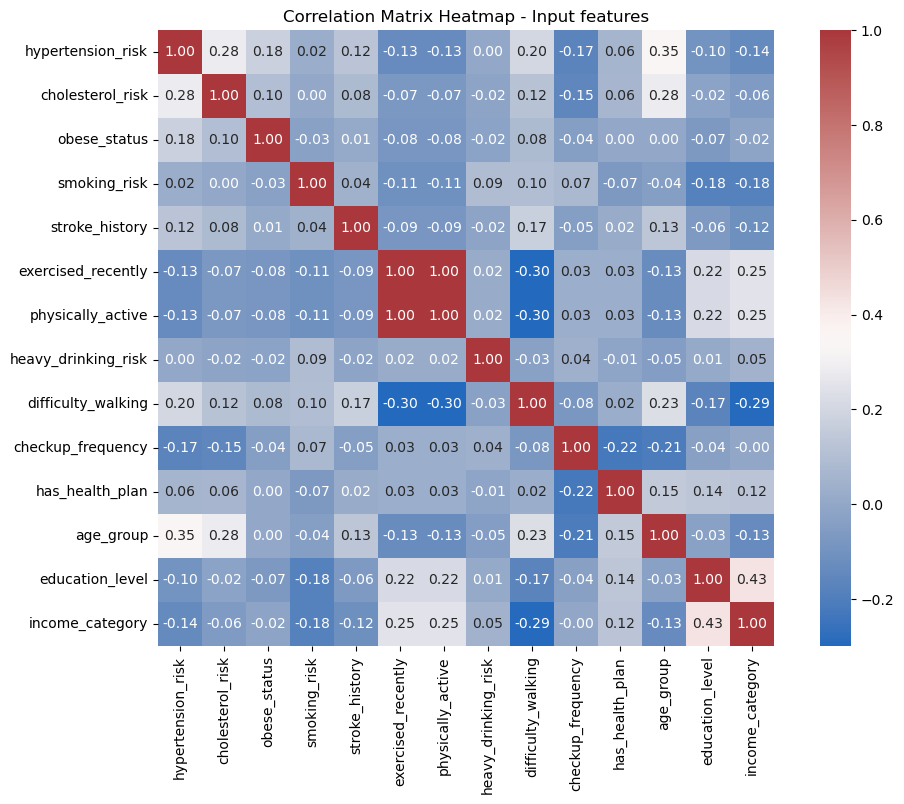

In [347]:
run_corr_matrix(input_df = cvd_model.drop('has_heart_disease', axis=1) ) 


- physically_active and exercised_recently are mapping 1:1 - we need to drop one of these features as they measure the same thing, similarly difficuly walking is measuring the same feature
- hypertension_risk and age are positively realted, which makes sense
- Similarly we see education and income are related, we need to perform featuire selection to ensure we dont have redudant data

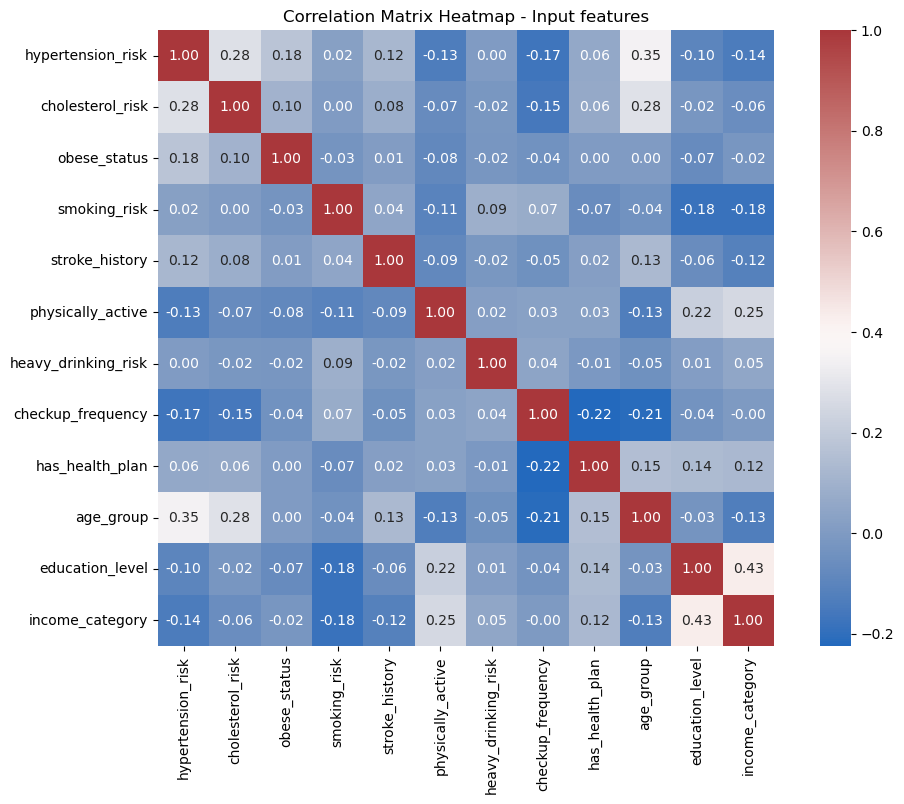

In [349]:
cvd_model = cvd_model.drop(['exercised_recently','difficulty_walking'], axis=1) 
run_corr_matrix(input_df = cvd_model.drop('has_heart_disease', axis=1) ) 

- These are better with no significant correlation, we can begin modeling this data
- y variable is has_heart_disease and rest all are features

              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95     48664
         1.0       0.48      0.05      0.09      4804

    accuracy                           0.91     53468
   macro avg       0.70      0.52      0.52     53468
weighted avg       0.87      0.91      0.87     53468



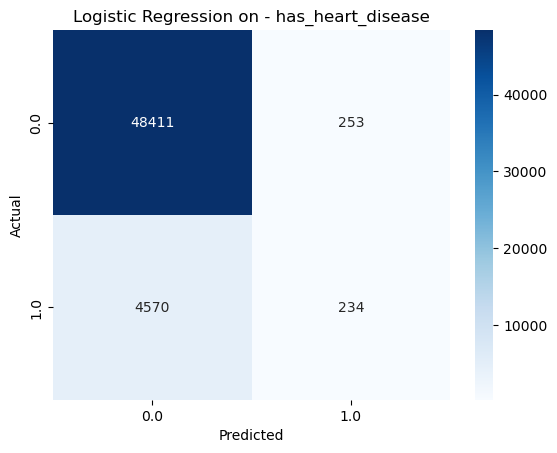

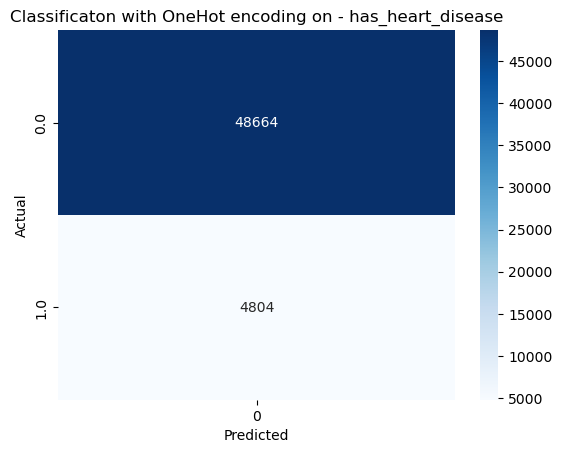

Accuracy: 0.9101518665369941
Macro Precision: 0.455
Macro Recall: 0.5
Weighted Precision: 0.828
Weighted Recall: 0.91
Micro Precision: 1.0
Micro Recall: 0.91


C:\Users\abhis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abhis\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [353]:

# run_onehot_classification(input_df = cvd_model, y_col_name = 'has_heart_disease')
run_logit_classification(input_df = cvd_model, y_col_name = 'has_heart_disease')
run_onehot_classification(input_df = cvd_model, y_col_name = 'has_heart_disease')


- We ran two mdoels here - logistic classification and onehot encoding classification. The results look good due to class imbalance, a majority of observations are y = 0 which is  no heart disease.
- We need to correct the class imbalance here for a better model

              precision    recall  f1-score   support

         0.0       0.75      0.70      0.72      4837
         1.0       0.71      0.76      0.74      4803

    accuracy                           0.73      9640
   macro avg       0.73      0.73      0.73      9640
weighted avg       0.73      0.73      0.73      9640



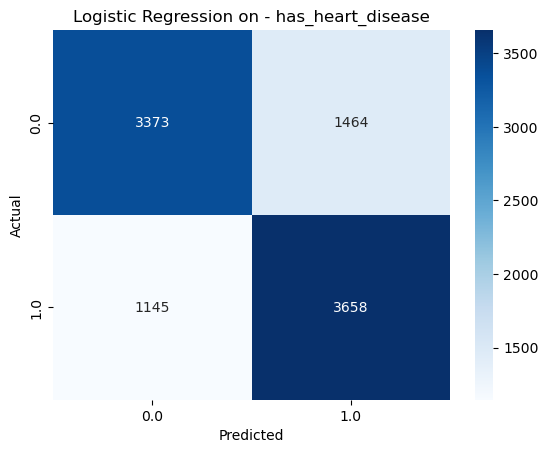

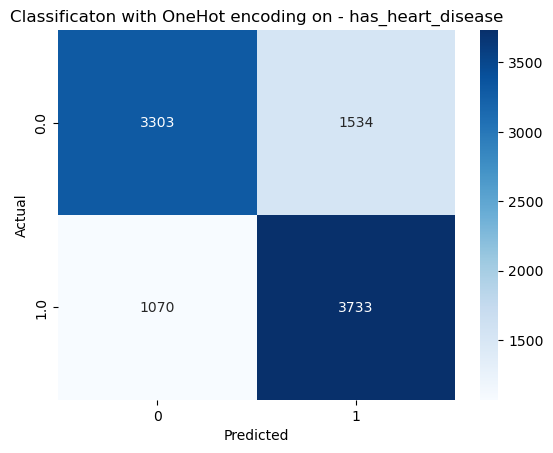

Accuracy: 0.7298755186721991
Macro Precision: 0.732
Macro Recall: 0.73
Weighted Precision: 0.732
Weighted Recall: 0.73
Micro Precision: 1.0
Micro Recall: 0.73


In [476]:
# This function will randomly sample the majority class to the min class number of observtaions
cvd_balanced = balance_classes_by_random_sampling(input_df=cvd_model, y_variable='has_heart_disease')
run_logit_classification(input_df = cvd_balanced, y_col_name = 'has_heart_disease')
run_onehot_classification(input_df = cvd_balanced, y_col_name = 'has_heart_disease')

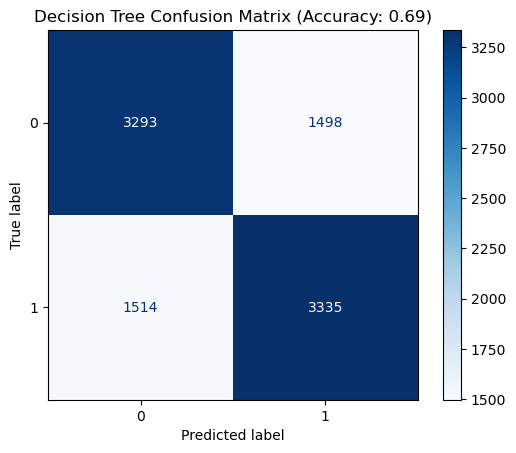

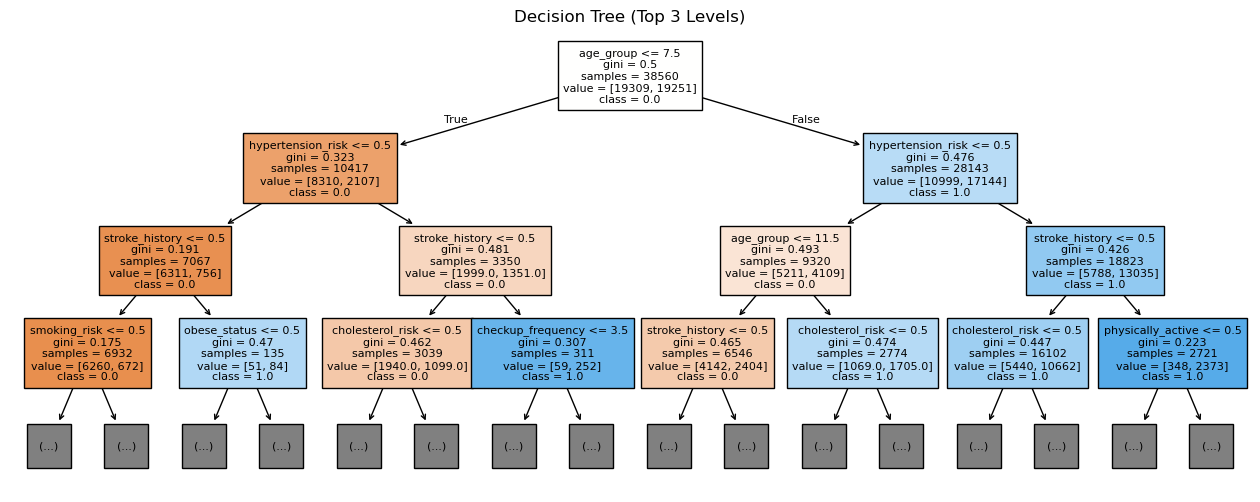

(DecisionTreeClassifier(random_state=42), 0.687551867219917)

In [370]:
run_decision_tree(input_df = cvd_balanced, y_col_name = 'has_heart_disease')

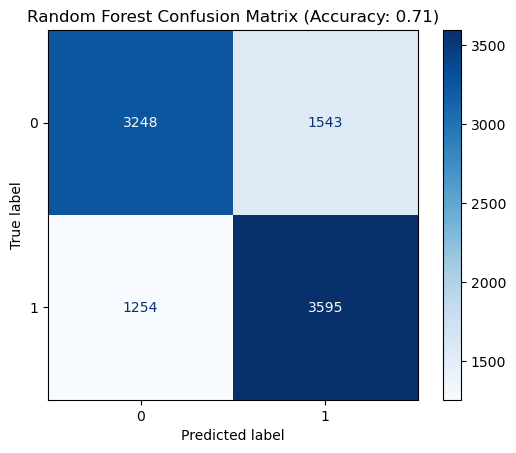

(RandomForestClassifier(random_state=42), 0.7098547717842324)

In [376]:
run_random_forest(input_df = cvd_balanced, y_col_name = 'has_heart_disease')

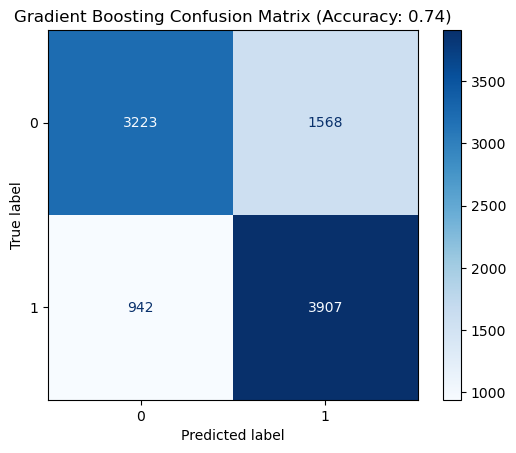

(GradientBoostingClassifier(random_state=42), 0.7396265560165975)

In [382]:
run_gradient_boosting(input_df = cvd_balanced, y_col_name = 'has_heart_disease')

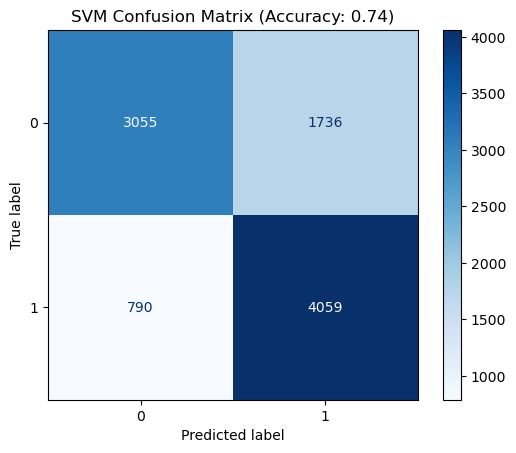

(SVC(random_state=42), 0.7379668049792532)

In [388]:
run_svm_classifier(input_df = cvd_balanced, y_col_name = 'has_heart_disease')

In [404]:

def run_knn_classifier(input_df, y_col_name, n_neighbors=1000):
    """
    Trains and evaluates a k-Nearest Neighbors (KNN) classifier on the input_df using y_col_name as the target.
    Plots the confusion matrix.
    Returns the fitted model and accuracy score.
    
    Parameters:
        input_df (pd.DataFrame): Input DataFrame.
        y_col_name (str): Name of the target column.
        n_neighbors (int): Number of neighbors to use for KNN (default=5).
    """
    # Prepare features and target
    X = input_df.drop(columns=[y_col_name])
    y = input_df[y_col_name]
    X = pd.get_dummies(X, drop_first=True)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Fit KNN
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"KNN Confusion Matrix (Accuracy: {acc:.2f})")
    plt.show()

    return clf, acc

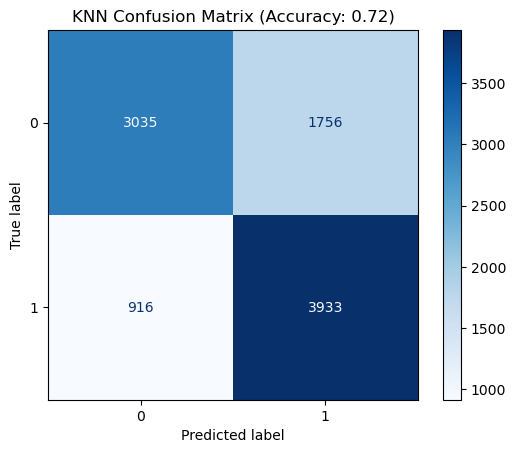

(KNeighborsClassifier(n_neighbors=1000), 0.7228215767634855)

In [406]:
run_knn_classifier(input_df = cvd_balanced, y_col_name = 'has_heart_disease')

In [408]:
def tune_knn_hyperparameters(input_df, y_col_name, k_range=None, cv_folds=5):
    """
    Performs hyperparameter tuning for KNN using k-fold cross-validation.
    Plots the mean cross-validated accuracy for each value of n_neighbors.
    Returns the best KNN model and its corresponding accuracy.
    
    Parameters:
        input_df (pd.DataFrame): Input DataFrame.
        y_col_name (str): Name of the target column.
        k_range (list or None): List of odd n_neighbors to try. If None, uses [3, 5, 11, 21, 51, 89, 101].
        cv_folds (int): Number of cross-validation folds.
    """
    if k_range is None:
        k_range = [3, 5, 11, 21, 51, 89, 101]
    
    X = input_df.drop(columns=[y_col_name])
    y = input_df[y_col_name]
    X = pd.get_dummies(X, drop_first=True)
    
    mean_accuracies = []
    std_accuracies = []
    
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X, y, cv=cv_folds, scoring='accuracy')
        mean_accuracies.append(scores.mean())
        std_accuracies.append(scores.std())
        print(f"k={k}: mean accuracy={scores.mean():.4f}, std={scores.std():.4f}")
    
    # Plotting
    plt.figure(figsize=(10,5))
    plt.errorbar(k_range, mean_accuracies, yerr=std_accuracies, fmt='-o', capsize=5)
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Mean CV Accuracy')
    plt.title(f'KNN Hyperparameter Tuning ({cv_folds}-fold CV)')
    plt.xticks(k_range)
    plt.show()
    
    # Best k
    best_idx = int(np.argmax(mean_accuracies))
    best_k = k_range[best_idx]
    print(f"Best k: {best_k} with mean accuracy: {mean_accuracies[best_idx]:.4f}")
    
    # Train best model on all data
    best_knn = KNeighborsClassifier(n_neighbors=best_k)
    best_knn.fit(X, y)
    
    return best_knn, best_k, mean_accuracies[best_idx]

In [ ]:
sample_size_sqrt = np.sqrt(cvd_balanced['has_heart_disease'].count())
k_range = [31, 71, 101,131,151,sample_size_sqrt,331,451]
tune_knn_hyperparameters(input_df = cvd_balanced, y_col_name = 'has_heart_disease',k_range=k_range, cv_folds=5)

In [500]:
summary_df, all_models_df = best_subset_selection_logistic_summary(df = cvd_model, target_col='has_heart_disease', max_features=None)
print(summary_df)

Total predictors 12
Running with 3 features
Running with 4 features
Running with 5 features
Running with 6 features
Running with 7 features
Running with 8 features
Running with 9 features
Running with 10 features
Running with 11 features
Running with 12 features
    k  BestAccuracy                                   FeaturesAccuracy  \
0   3      0.909852  (hypertension_risk, cholesterol_risk, obese_st...   
1   4      0.909864  (smoking_risk, physically_active, age_group, i...   
2   5      0.909864  (smoking_risk, physically_active, heavy_drinki...   
3   6      0.909860  (smoking_risk, physically_active, heavy_drinki...   
4   7      0.909852  (hypertension_risk, cholesterol_risk, obese_st...   
5   8      0.909852  (hypertension_risk, cholesterol_risk, obese_st...   
6   9      0.909852  (hypertension_risk, cholesterol_risk, obese_st...   
7  10      0.909852  (hypertension_risk, cholesterol_risk, obese_st...   
8  11      0.909654  (hypertension_risk, cholesterol_risk, obese_st... 

In [505]:
summary_df.columns


Index(['k', 'BestAccuracy', 'FeaturesAccuracy', 'BestPrecision',
       'FeaturesPrecision', 'BestRecall', 'FeaturesRecall'],
      dtype='object')

In [507]:
summary_df

,k,BestAccuracy,FeaturesAccuracy,BestPrecision,FeaturesPrecision,BestRecall,FeaturesRecall
0,3,0.909852,"(hypertension_risk, cholesterol_risk, obese_st...",0.486486,"(stroke_history, physically_active, education_...",0.053444,"(hypertension_risk, stroke_history, age_group)"
1,4,0.909864,"(smoking_risk, physically_active, age_group, i...",0.714286,"(smoking_risk, physically_active, age_group, i...",0.053444,"(hypertension_risk, stroke_history, has_health..."
2,5,0.909864,"(smoking_risk, physically_active, heavy_drinki...",0.714286,"(smoking_risk, physically_active, heavy_drinki...",0.061120,"(hypertension_risk, stroke_history, physically..."
3,6,0.909860,"(smoking_risk, physically_active, heavy_drinki...",0.666667,"(smoking_risk, physically_active, heavy_drinki...",0.059046,"(hypertension_risk, obese_status, stroke_histo..."
4,7,0.909852,"(hypertension_risk, cholesterol_risk, obese_st...",0.500000,"(obese_status, smoking_risk, heavy_drinking_ri...",0.058174,"(hypertension_risk, obese_status, stroke_histo..."
5,8,0.909852,"(hypertension_risk, cholesterol_risk, obese_st...",0.500000,"(obese_status, smoking_risk, heavy_drinking_ri...",0.052490,"(hypertension_risk, obese_status, smoking_risk..."
6,9,0.909852,"(hypertension_risk, cholesterol_risk, obese_st...",0.485404,"(hypertension_risk, smoking_risk, stroke_histo...",0.050000,"(hypertension_risk, cholesterol_risk, obese_st..."
7,10,0.909852,"(hypertension_risk, cholesterol_risk, obese_st...",0.485404,"(hypertension_risk, obese_status, smoking_risk...",0.049253,"(hypertension_risk, cholesterol_risk, obese_st..."
8,11,0.909654,"(hypertension_risk, cholesterol_risk, obese_st...",0.480325,"(hypertension_risk, cholesterol_risk, obese_st...",0.047801,"(hypertension_risk, cholesterol_risk, obese_st..."
9,12,0.909463,"(hypertension_risk, cholesterol_risk, obese_st...",0.478206,"(hypertension_risk, cholesterol_risk, obese_st...",0.047344,"(hypertension_risk, cholesterol_risk, obese_st..."


[('hypertension_risk', 'cholesterol_risk', 'obese_status'), ('smoking_risk', 'physically_active', 'age_group', 'income_category'), ('smoking_risk', 'physically_active', 'heavy_drinking_risk', 'age_group', 'income_category'), ('smoking_risk', 'physically_active', 'heavy_drinking_risk', 'has_health_plan', 'age_group', 'income_category'), ('hypertension_risk', 'cholesterol_risk', 'obese_status', 'smoking_risk', 'physically_active', 'heavy_drinking_risk', 'checkup_frequency'), ('hypertension_risk', 'cholesterol_risk', 'obese_status', 'smoking_risk', 'physically_active', 'heavy_drinking_risk', 'checkup_frequency', 'has_health_plan'), ('hypertension_risk', 'cholesterol_risk', 'obese_status', 'smoking_risk', 'physically_active', 'heavy_drinking_risk', 'checkup_frequency', 'has_health_plan', 'education_level'), ('hypertension_risk', 'cholesterol_risk', 'obese_status', 'smoking_risk', 'physically_active', 'heavy_drinking_risk', 'checkup_frequency', 'has_health_plan', 'education_level', 'income_

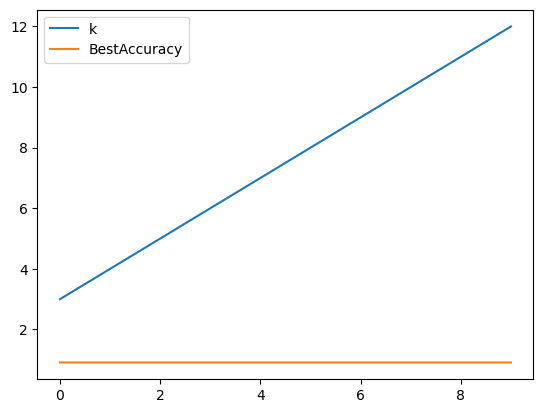

In [529]:
summary_df.loc[:,['k', 'BestAccuracy', ]].plot()
summary_df.loc[:,['k', 'BestAccuracy', ]]

print(summary_df.loc[:, 'FeaturesAccuracy'].to_list())

# Project Outline: Predicting Cardiovascular Disease Risk Using CDC BRFSS Data

## 1. Dataset Selection

For this project, I have chosen a dataset that is both extensive and relatively underutilized compared to classic datasets like Iris or Wine. The dataset is the **Behavioral Risk Factor Surveillance System (BRFSS)**, available from the Centers for Disease Control and Prevention (CDC).

- **Data Context:** The BRFSS is the largest continuously conducted health survey system in the world. It collects health-related risk behaviors, chronic health conditions, and preventive service usage from adults in the United States via phone surveys.
- **Why this dataset?** It provides a rich set of variables on health, social, and economic factors, and is not among the typical datasets used in introductory data science projects.

**Links:**
- [BRFSS Introduction](https://www.cdc.gov/brfss/index.html)
- [BRFSS Data Documentation](https://www.cdc.gov/brfss/data_documentation/index.htm)
- [2023 BRFSS Data Download](https://www.cdc.gov/brfss/annual_data/annual_2023.html)

---

## 2. Learning Question

**Main Question:**  
*Can we predict whether an individual has ever been diagnosed with a heart attack based on their health, social, and economic factors?*

- **Target variable (Y):** Ever diagnosed with a heart attack? (categorical: Yes/No/Other)
- **Predictor variables (X):**
  - *Health Factors:* Age, BMI, frequency of health checkups, family history of disease
  - *Social & Economic Factors:* Education, income, access to healthcare and insurance

**Relevance:**  
Understanding these risk factors is critical, as cardiovascular disease is the leading cause of death in the US. This project could help:
- **Individuals:** Remind them of the importance of healthy lifestyle choices.
- **Policymakers:** Guide policy for reducing heart disease prevalence and improving healthcare access.
- **Companies (e.g., food/consumer staples):** Encourage product offerings or campaigns that support healthy living.

---

## 3. Dataset Details

- **Size:** Over 425,000 survey responses are available for recent years, ensuring ample data for robust analysis.
- **Problem Type:** Primarily a *classification* problem (predicting “Yes” or “No” for heart attack diagnosis). If appropriate, I might also explore regression techniques to estimate risk probabilities or model feature impacts.

---

## 4. Model Selection and Justification

Given the project’s goals and dataset characteristics, I propose to try several models:

- **Logistic Regression:**  
  A classic method for binary classification. If I recode the outcome as “Yes” or “No,” logistic regression will help identify which features are most predictive.
- **Decision Trees / Random Forests:**  
  Useful for handling categorical variables and non-linear relationships. Random forests can also help with feature importance analysis and reduce overfitting.
- **k-Nearest Neighbors (k-NN):**  
  As a baseline, I may use k-NN for comparison, though it may not scale as well with very large datasets.

**Potential Challenges:**
- **Class Imbalance:** There may be many more respondents without a heart attack than with one, which could bias models.
- **Survivorship Bias:** Only living respondents are included, which is important to note when interpreting results.

---

## 5. Summary

This project will use the CDC BRFSS dataset to explore and model the risk factors for heart attacks in the US population, using a range of machine learning techniques suitable for classification. The findings could inform individuals, policymakers, and organizations about the most significant predictors of heart disease, and support efforts to promote healthier lifestyles.
